# 07 — Market Attractiveness & Strategic Analysis

## Objective

Translate the quantitative findings from Notebooks 01–06 into a transparent market attractiveness ranking and explicit business/strategic implications, using the DATA → INSIGHT → BUSINESS IMPLICATION → STRATEGIC CONSIDERATION structure throughout.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src/visualisation')
attract = pd.read_csv('../outputs/tables/market_attractiveness_ranking.csv')
attract[['rank','Country','Project_007_Region','market_attractiveness_score']].head(15)

,rank,Country,Project_007_Region,market_attractiveness_score
0,1,United States,North America,90.080127
1,2,Switzerland,Europe,65.250454
2,3,Norway,Europe,63.203699
3,4,Luxembourg,Europe,62.996995
4,5,Australia,Oceania,60.742618
5,6,Iceland,Europe,59.472649
6,7,United Kingdom,Europe,59.261018
7,8,United Arab Emirates,Middle East,58.719916
8,9,Qatar,Middle East,57.574970
9,10,"Hong Kong SAR, China",East Asia,57.487037


## Methodology Summary

Four equally-weighted pillars — Market Size, Market Growth, Spending Power, Digital Readiness — each min-max normalised to 0-100, averaged. Equal weighting is a **deliberate, documented simplification**, not a data-optimised result; a sensitivity check re-running the score with growth double-weighted produced a Spearman rank correlation of **0.985** against the base ranking — the ranking is not fragile to this particular weighting choice. Full methodology: [`docs/MARKET_ATTRACTIVENESS_METHODOLOGY.md`](../docs/MARKET_ATTRACTIVENESS_METHODOLOGY.md).

In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
import matplotlib.pyplot as plt

ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


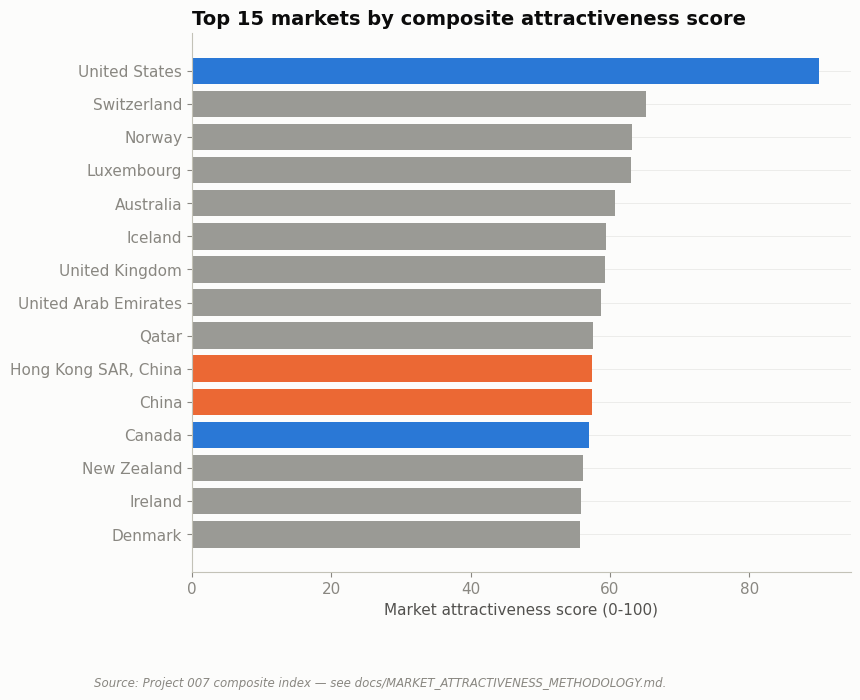

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 7))
top15 = attract.head(15).sort_values('market_attractiveness_score')
colors = [ACCENT_1 if r=='North America' else (ACCENT_2 if r=='East Asia' else GRAY) for r in top15['Project_007_Region']]
ax.barh(top15['Country'], top15['market_attractiveness_score'], color=colors)
ax.set_title('Top 15 markets by composite attractiveness score', loc='left')
ax.set_xlabel('Market attractiveness score (0-100)')
add_source(ax.figure, 'Source: Project 007 composite index \u2014 see docs/MARKET_ATTRACTIVENESS_METHODOLOGY.md.')
plt.show()

## Strategic Findings

### Finding 1 — Scale markets and growth markets are largely different countries

**DATA:** The United States, China, Japan, Germany, and the UK hold the largest absolute consumer-spending bases; South & Southeast Asian and African countries post the fastest real growth rates, but individually contribute far less to the global total.

**INSIGHT:** Market size and market growth are close to orthogonal in this dataset — a country ranking well on one frequently ranks poorly on the other.

**BUSINESS IMPLICATION:** A single global market-entry strategy is unlikely to be appropriate across both groups; "defend share in large mature markets" and "build early position in high-growth markets" are two different playbooks with different time horizons and risk profiles.

**STRATEGIC CONSIDERATION:** Businesses may need a genuinely two-track international strategy — capital-intensive scale plays in Tier 1 mature markets, and lower-cost, longer-horizon early entry in identified high-growth markets — rather than a single resourcing model applied everywhere.

### Finding 2 — Digital readiness is now a market-maturity marker, not a differentiator

**DATA:** Internet penetration is associated with higher spending per capita (r=0.61) but *negatively* associated with spending growth (r=-0.22, i.e. already-online markets grow slower).

**INSIGHT:** High digital penetration appears consistent with market maturity rather than being itself a growth driver at this point in the global cycle — the highest-growth markets (Lower-Spending Developing segment) still have meaningfully lower internet penetration (~45% median) with room to expand.

**BUSINESS IMPLICATION:** "Digital-first" market entry may be table stakes in Mature and Emerging Upper-Middle segments, but in the Lower-Spending Developing segment, digital infrastructure build-out itself may be the more consequential near-term opportunity, not just digitally-enabled retail on top of existing infrastructure.

**STRATEGIC CONSIDERATION:** Market entry sequencing might reasonably prioritise digital-infrastructure-adjacent categories (payments, logistics, connectivity-dependent services) ahead of pure consumer retail in the fastest-growing but least-digitised markets.

### Finding 3 — Macro instability can invalidate standard market-attractiveness signals entirely

**DATA:** Argentina and Lebanon combine mid-tier income, high urbanisation, and high internet penetration — metrics that would otherwise suggest an attractive market — with severe currency/inflation crises and negative real consumption growth.

**INSIGHT:** A composite score built from typical macro/demographic indicators can misrate a market if it does not separately account for macro stability — these two countries scored moderately on three of four pillars despite being in active economic crisis.

**BUSINESS IMPLICATION:** A market-attractiveness screen used for real capital-allocation decisions should treat currency and inflation stability as a gating filter, not just one input averaged with the others.

**STRATEGIC CONSIDERATION:** Businesses evaluating these two markets specifically (or others that later enter a similar crisis pattern) may need local-currency hedging, phased/reversible investment structures, or to defer entry until stabilisation, regardless of otherwise-attractive demographic or digital fundamentals.

## Limitations of This Strategic Layer

These are evidence-consistent interpretations of the patterns found in Notebooks 01–06, not verified causal business outcomes. See [`docs/LIMITATIONS.md`](../docs/LIMITATIONS.md) for the full discussion of what this analysis can and cannot support.